# 11-07-2026 Logistic Regression Assignment
## Renewable Share Energy Dataset

Saving 01 renewable-share-energy.csv to 01 renewable-share-energy.csv
(5603, 4)
Index(['Entity', 'Code', 'Year', 'Renewables (% equivalent primary energy)'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5603 entries, 0 to 5602
Data columns (total 4 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Entity                                    5603 non-null   object 
 1   Code                                      4292 non-null   object 
 2   Year                                      5603 non-null   int64  
 3   Renewables (% equivalent primary energy)  5603 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 175.2+ KB
None
        Entity  Code         Year  Renewables (% equivalent primary energy)
count     5603  4292  5603.000000                               5603.000000
unique     104    81          NaN                                       N

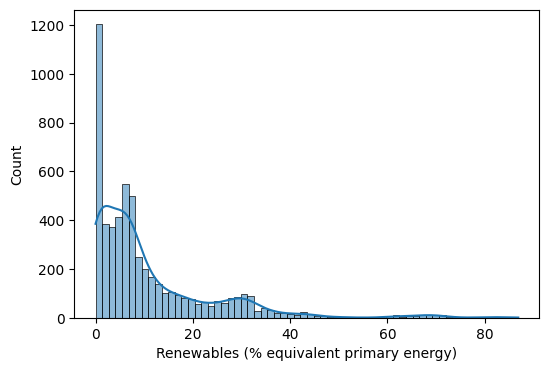

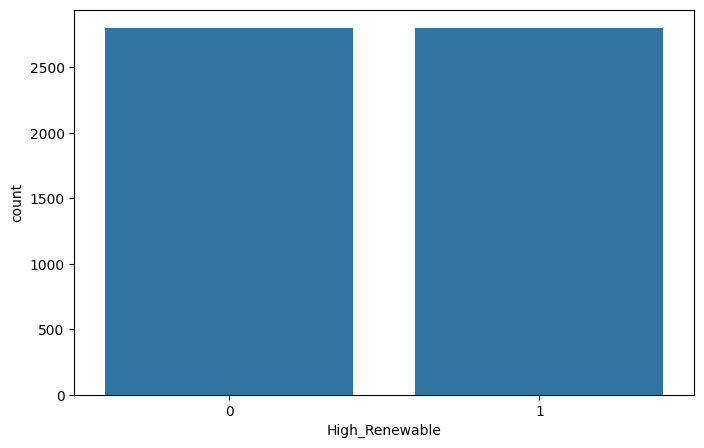

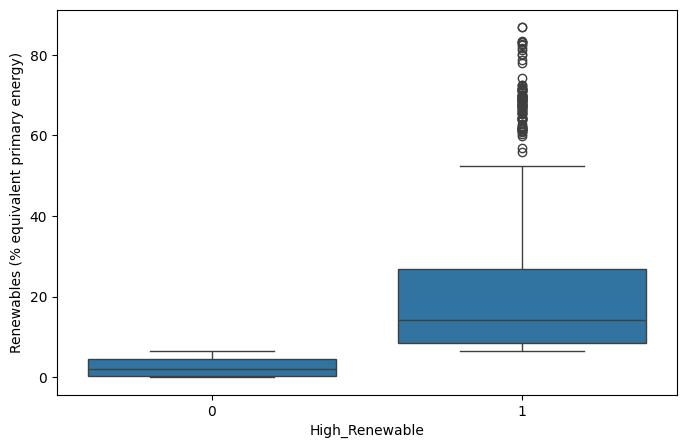

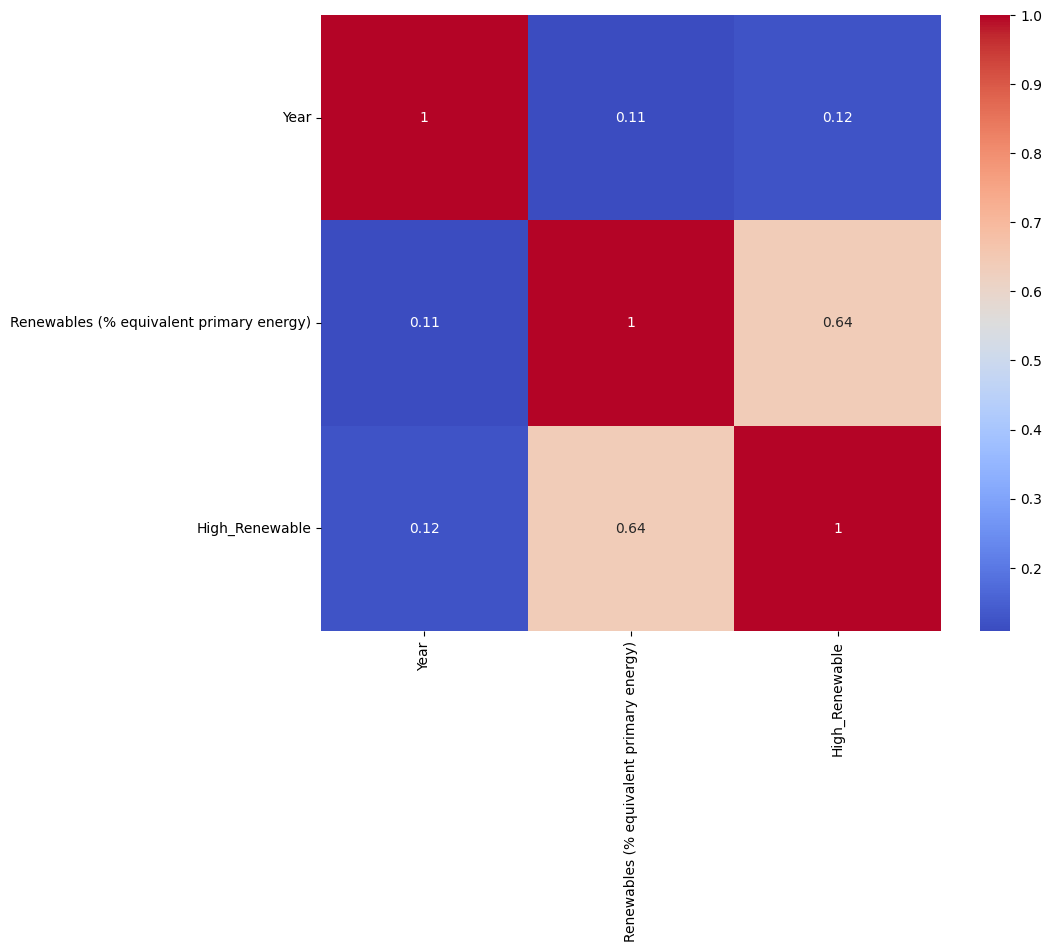

Accuracy: 0.5744870651204282

Confusion Matrix
[[317 239]
 [238 327]]

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.57      0.57       556
           1       0.58      0.58      0.58       565

    accuracy                           0.57      1121
   macro avg       0.57      0.57      0.57      1121
weighted avg       0.57      0.57      0.57      1121



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

print(df.shape)
print(df.columns)
print(df.info())
print(df.describe(include='all'))
print(df.isnull().sum())

# Handle Missing Values

numeric = df.select_dtypes(include=np.number).columns
categorical = df.select_dtypes(include='object').columns

df[numeric] = df[numeric].fillna(df[numeric].median())

for col in categorical:
    df[col] = df[col].fillna("Unknown")

renewable_col = df.columns[-1]

df["High_Renewable"] = (
    df[renewable_col] >= df[renewable_col].median()
).astype(int)

df.head()

plt.figure(figsize=(6,4))
sns.histplot(df[renewable_col], kde=True)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x="High_Renewable", data=df)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="High_Renewable", y=renewable_col, data=df)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.show()

encoder = LabelEncoder()

if "Entity" in df.columns:
    df["Entity"] = encoder.fit_transform(df["Entity"])

if "Code" in df.columns:
    df["Code"] = encoder.fit_transform(df["Code"].astype(str))

feature_cols = []

for col in ["Entity","Code","Year"]:
    if col in df.columns:
        feature_cols.append(col)

X = df[feature_cols]
y = df["High_Renewable"]

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))



## Generalisations

- Each row represents a country (or region) and a year.
- Renewable share indicates the percentage of energy obtained from renewable sources.
- Higher renewable share indicates greater dependence on clean energy.
- The dataset helps analyse renewable energy adoption over time.



## Feature Relationships

- Year helps analyse renewable energy trends over time.
- Entity represents the country/region.
- Renewable Share is the main sustainability indicator.
- Different countries adopt renewable energy at different rates.



## Feature Engineering

Create a binary target:

- 1 = High Renewable Share
- 0 = Low Renewable Share

using the median renewable share.



## Model Insights

- Label Encoding converts categorical values into numbers.
- StandardScaler ensures numerical features are on a similar scale.
- Train-Test Split evaluates the model on unseen data.
- Logistic Regression predicts whether renewable share is High or Low.
- Accuracy indicates the proportion of correct predictions.
- Precision measures how many predicted positives are correct.
- Recall measures how many actual positives were identified.
- F1-score balances Precision and Recall.



## Conclusion

- Imported the sustainability dataset.
- Explored and analysed the data.
- Handled missing values.
- Created a binary target using feature engineering.
- Applied Label Encoding and Standard Scaling.
- Split the dataset into training and testing sets.
- Built a Logistic Regression model.
- Evaluated the model using Accuracy, Confusion Matrix and Classification Report.
